This notebook was made for plotting nBodySimulation results.

In [ ]:
import subprocess
import os
import json
import pandas as pd
import matplotlib.pyplot as plt


Choose which methods to include. The currently supported options are vulkan_cells, vulkan_naive, cpp_naive

Also choose whether or not to force rerun the benchmarks. Alternatively, old runs will be used (if available)

In [ ]:
incl = ["vulkan_naive", "vulkan_cells", "vulkan_verlet", "slang->vulkan_naive", "slang->vulkan_cells", "slang->vulkan_verlet", "slang->ptx_naive", "slang->ptx_cells", "slang->ptx_verlet", "cpp_naive"]
force_rerun = True
draw_median = True

executables = {
    "vulkan_naive"         : "../build/src/nBodySimulation/vulkan/naive/nbody_vulkan_naive",
    "vulkan_cells"         : "../build/src/nBodySimulation/vulkan/cell_lists/nbody_vulkan_cells",
    "vulkan_verlet"        : "../build/src/nBodySimulation/vulkan/verlet_lists/nbody_vulkan_verlet",
    "slang->vulkan_naive"  : "../build/src/nBodySimulation/slang/naive/nbody_slang_vulkan_naive", 
    "slang->vulkan_cells"  : "../build/src/nBodySimulation/slang/cell_lists/nbody_slang_vulkan_cells", 
    "slang->vulkan_verlet" : "../build/src/nBodySimulation/slang/verlet_lists/nbody_slang_vulkan_verlet", 
    "slang->ptx_naive"     : "../build/src/nBodySimulation/slang/naive/nbody_slang_cuda_naive", 
    "slang->ptx_cells"     : "../build/src/nBodySimulation/slang/cell_lists/nbody_slang_cuda_cells", 
    "slang->ptx_verlet"    : "../build/src/nBodySimulation/slang/verlet_lists/nbody_slang_cuda_verlet", 
    "cpp_naive"            : "../build/src/nBodySimulation/cpp/nbody_cpp"
}


results = {
    "vulkan_naive"         : "../results/nBody_vulkan_naive.json",
    "vulkan_cells"         : "../results/nBody_vulkan_cells.json",
    "vulkan_verlet"        : "../results/nBody_vulkan_verlet.json",
    "slang->vulkan_naive"  : "../results/nBody_slang_vulkan_naive.json", 
    "slang->vulkan_cells"  : "../results/nBody_slang_vulkan_cells.json", 
    "slang->vulkan_verlet" : "../results/nBody_slang_vulkan_verlet.json", 
    "slang->ptx_naive"     : "../results/nBody_slang_cuda_naive.json", 
    "slang->ptx_cells"     : "../results/nBody_slang_cuda_cells.json", 
    "slang->ptx_verlet"    : "../results/nBody_slang_cuda_verlet.json", 
    "cpp_naive"            : "../results/nBody_cpp_naive.json"
}
        

In [ ]:
def run_benchmark(method):
    print("Now running " + method + " benchmark...")
    executable_path = executables[method]
    result_path = results[method]
    command = [executable_path, f"--benchmark_out={result_path}", "--benchmark_out_format=json"]
    result = subprocess.run(command, capture_output=True, text=True, check=True)
    print(result.stdout, "\n")

def file_exists(filepath):
    return os.path.exists(filepath)

def validate_json_file(method):
    try:
        with open(results[method]) as f:
            json.load(f)
        return True
    except:
        return False

def run_cmake():
    cmake = subprocess.run(["cmake", "--build", "../build"], capture_output=True, text=True, check=True)
    print(cmake.stdout, "\n")
        

In [59]:
run_cmake()
if force_rerun:
    for method in incl:
        if not file_exists(executables[method]):
            raise FileNotFoundError(f"The executable for {method} was not found in the build directory. Reconfigure the project to build the correct files!")
    for method in incl:
        run_benchmark(method=method)
else:
    for method in incl:
        if not file_exists(results[method]):
            print(f"Could not find results for {method}...")
            if not file_exists(executables[method]):
                raise FileNotFoundError(f"The executable for {method} was not found in the build directory. Reconfigure the project to build the correct files!")
            run_benchmark(method)
        if not validate_json_file(method):
            print(f"Could not validate json results file for {method}.")
            run_benchmark(method)

for method in incl:
    if not validate_json_file(method):
        raise FileNotFoundError(f"The result file for {method} was not found or could not be opened.")
        

[1/21] Building CXX object src/nBodySimulation/slang/cell_lists/CMakeFiles/nbody_slang_vulkan_cells.dir/main.cpp.o
In file included from /home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/Particle.h:9,
                 from /home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/NBodySimulation.h:21,
                 from /home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/slang/cell_lists/Impl_Slang_Vulkan.h:2,
                 from /home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/nBodySimulation/slang/cell_lists/main.cpp:2:
/home/moritzbeste/Documents/projects/uni/bachelorarbeit/performance-portability-benchmark/src/common/UtilityFloatArithmetic.h:73:90: warning: ‘host’ attribute directive ignored [-Wattributes]
   73 |     __attribute__((host)) __attribute__((device)) in

KeyboardInterrupt: 

Now all results should exist. Next the files need to be read.


In [ ]:
def add_problem_size_column(df):
    df = df.copy()

    df = df[~df["name"].str.contains(r"_(?:mean|median|stddev)$", regex=True)]
    extracted = df["name"].str.extract(r"/(\d+)(?:/|$)")[0]

    if extracted.isna().any():
        bad = df.loc[extracted.isna(), "name"].unique()
        raise ValueError(f"Could not extract problem size N from:\n{bad}")

    df["N"] = extracted.astype(int)
    return df


def add_problem_size_column_median_only(df):
    df = df.copy()

    df = df[df["name"].str.contains(r"_median$", regex=True)]
    extracted = df["name"].str.extract(r"/(\d+)(?:/|_)")[0]

    if extracted.isna().any():
        bad = df.loc[extracted.isna(), "name"].unique()
        raise ValueError(f"Could not extract N from:\n{bad}")

    df["N"] = extracted.astype(int)
    return df


In [ ]:
dataframes = {}
for method in incl:
    with open(results[method], 'r') as f:
        data = json.load(f)
    benchmarks = data["benchmarks"]
    
    df = pd.DataFrame(benchmarks)
    if draw_median:
        df = df[df["name"].str.endswith("_median")]
    else:
        df = df[df["run_type"] == "iteration"]
    df = df.drop(columns=["family_index", "per_family_instance_index", "run_name", 
        "run_type", "repetitions", "repetition_index", 
        "threads", "iterations", "cpu_coefficient", 
        "real_coefficient", "big_o", "rms", 
        "aggregate_name", "aggregate_unit"])
    df["real_time_s"] = df["real_time"] / 1e9
    df["cpu_time_s"]  = df["cpu_time"]  / 1e9

    if draw_median:
        dataframes[method] = add_problem_size_column_median_only(df)
    else:
        dataframes[method] = add_problem_size_column(df)

Now we display the results in matplotlib graphs.

In [ ]:
def plot_single(df, title, git_hash=None):
    plt.figure(figsize=(8,5))
    plt.plot(df["N"], df["real_time_s"], marker="o")
    plt.xscale("log")
    plt.xlabel("N (problem size)")
    plt.ylabel("Real time (s)")
    plt.title(title)
    plt.grid(True)

    if git_hash:
        plt.figtext(
            0.5, -0.05,
            f"git hash: {git_hash}",
            ha="center", fontsize=8, color="gray"
        )

    plt.show()

def plot_overlay(dataframes, git_hash=None):
    plt.figure(figsize=(8,5))

    for label, df in dataframes.items():
        df = add_problem_size_column_median_only(df)
        plt.plot(df["N"], df["real_time_s"], marker="o", label=label)

    plt.xscale("log")
    plt.xlabel("N (problem size)")
    plt.ylabel("Real time (s)")
    plt.title("Benchmark Comparison")
    plt.grid(True)
    plt.legend()

    if git_hash:
        plt.figtext(
            0.5, -0.05,
            f"git hash: {git_hash}",
            ha="center", fontsize=8, color="gray"
        )

    plt.show()


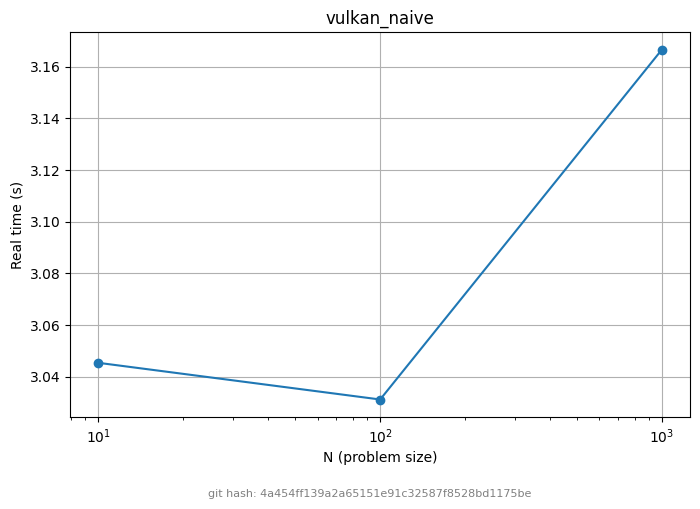

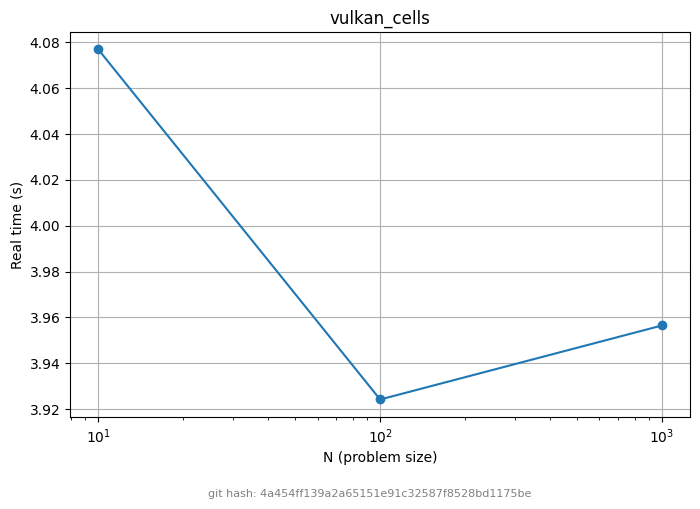

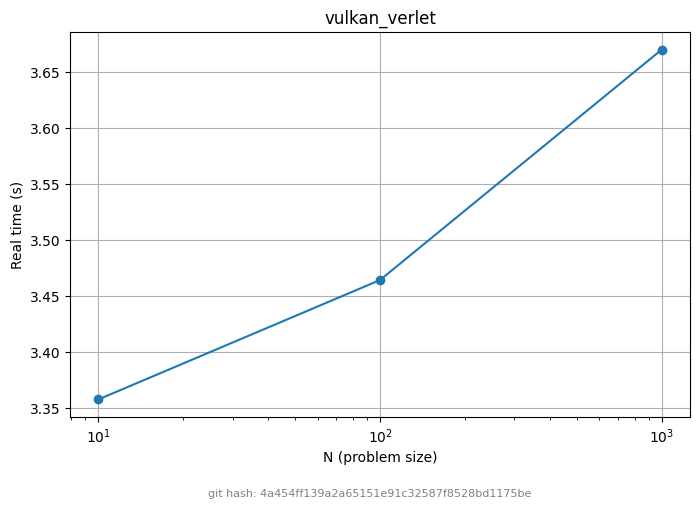

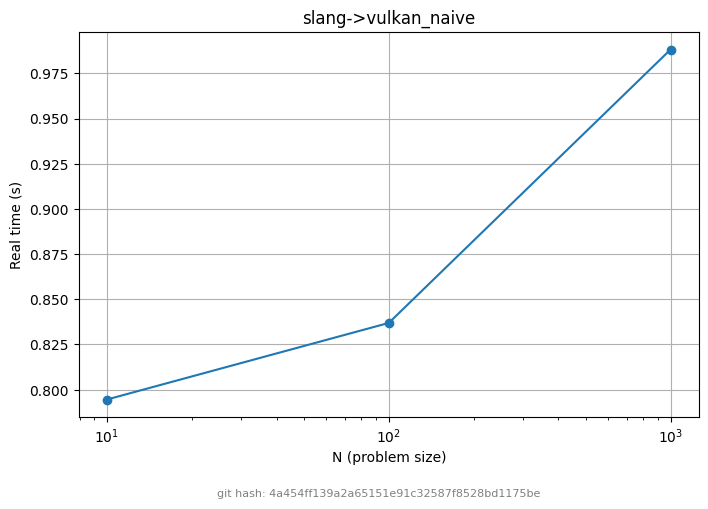

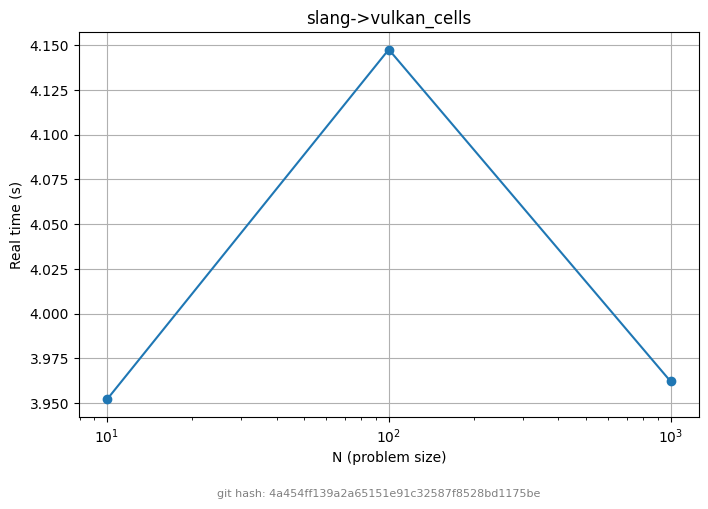

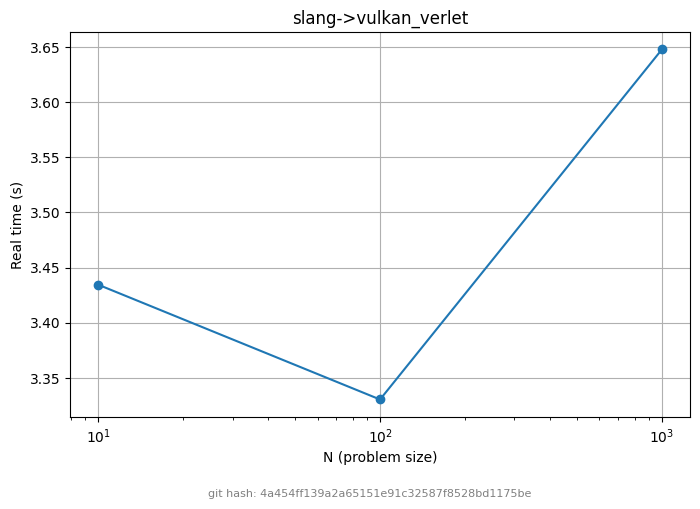

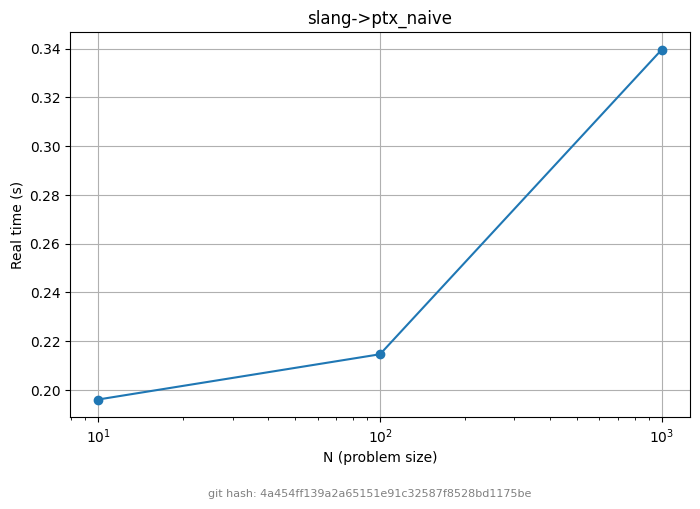

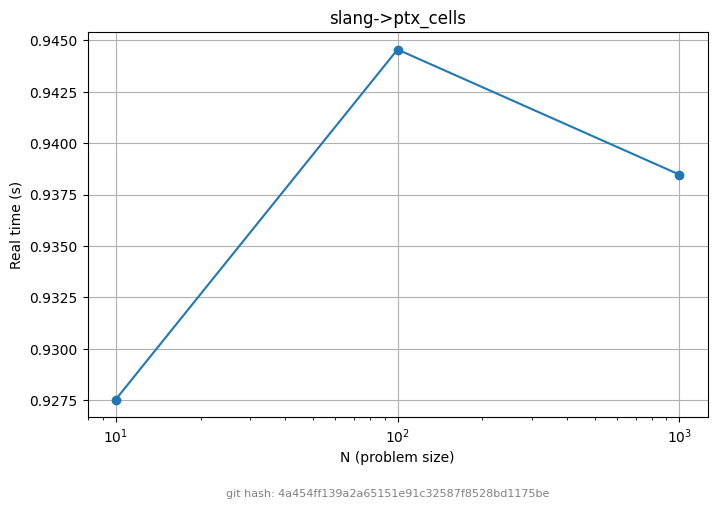

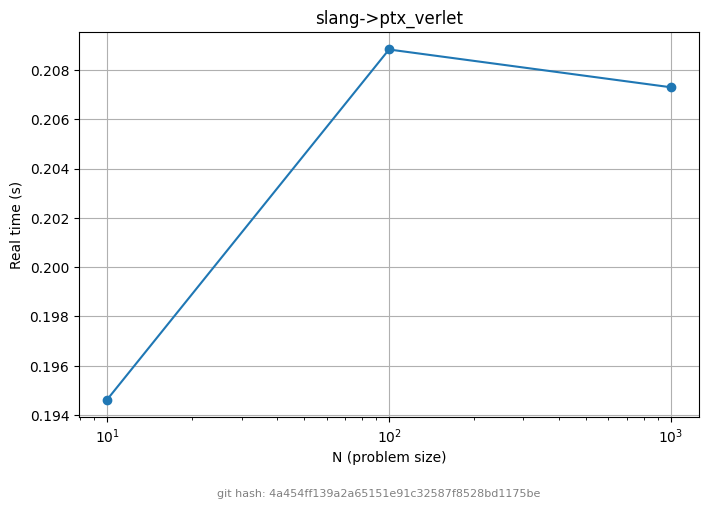

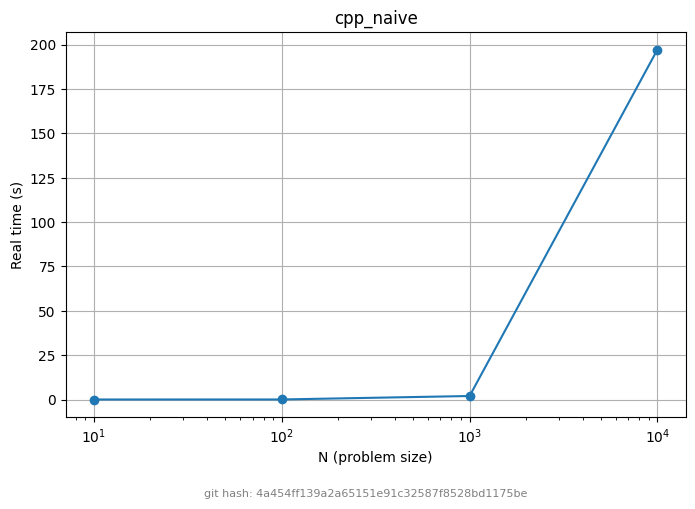

In [ ]:
git_hash = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()

for method in incl:
    plot_single(dataframes[method], method, git_hash)

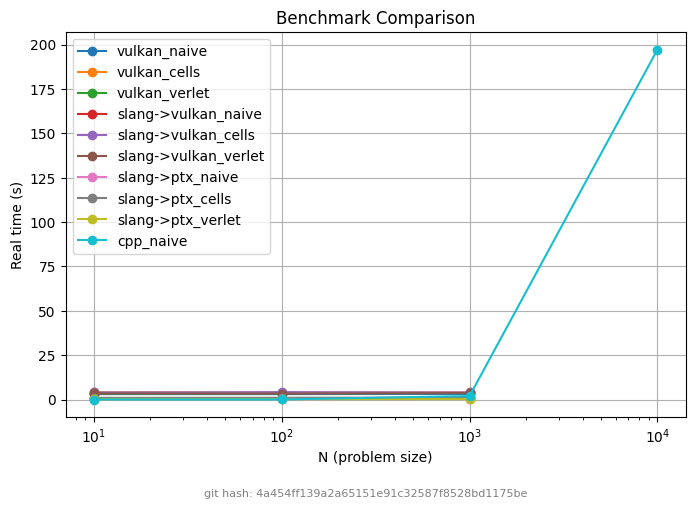

In [ ]:
plot_overlay(dataframes, git_hash)